In [50]:
import os
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Complete model

In [51]:


model_dir = "incomplete_21_2026-04-17_10-13-55_f3d9e"


def extract_info_from_intervention_log(model_dir):
    experiment_path = os.path.join("experiments", "scbm", "CUB")
    concepts_intervened_list = []
    y_accuracies_list = []
    c_accuracies_list = []




    with open(os.path.join(experiment_path, model_dir, "intervention_log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "y_accuracy" and "c_accuracy" and "Intervention on" in line:
                concepts_intervened, y_accuracy, c_accuracy = re.findall(r"Intervention on (\d+) concepts:.*?y_accuracy:\s*([0-9.]+)\s+c_accuracy:\s*([0-9.]+)", line)[0]
                concepts_intervened = int(concepts_intervened)
                y_accuracy = float(y_accuracy) * 100
                c_accuracy = float(c_accuracy) * 100

                concepts_intervened_list.append(concepts_intervened)
                y_accuracies_list.append(y_accuracy)
                c_accuracies_list.append(c_accuracy)
    return concepts_intervened_list, y_accuracies_list, c_accuracies_list


            
            




In [52]:
def plot_intervention_curves(ax, concepts_intervened_list, accuracy_list, color):

    ax.plot(
        concepts_intervened_list,
        accuracy_list,
        
        linewidth=2.2,
        markersize=6,
        color=color,
        label=r"Accuracy of joint model trained on complete dataset (0% concept groups removed)",
    )

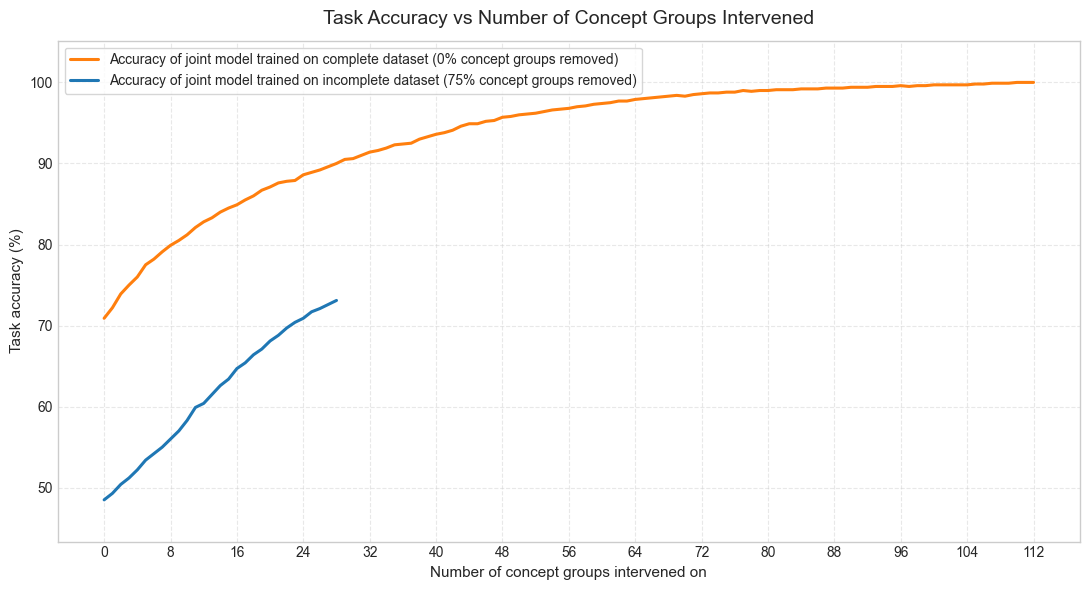

In [53]:
model_dir_complete = "Stephen_2026-04-15_22-03-14_a3d81"
model_dir_incomplete_rmv_21 = "incomplete_21_2026-04-17_15-40-39_8e524_cluster"
concepts_intervened_list_complete, y_accuracies_list_complete, c_accuracies_list_complete = extract_info_from_intervention_log(model_dir_complete)
concepts_intervened_list_incomplete_rmv_21, y_accuracies_list_incomplete_rmv_21, c_accuracies_list_incomplete_rmv_21 = extract_info_from_intervention_log(model_dir_incomplete_rmv_21)

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    concepts_intervened_list_complete,
    y_accuracies_list_complete,
    linewidth=2.2,
    markersize=6,
    color="#ff7f0e",
    label=r"Accuracy of joint model trained on complete dataset (0% concept groups removed)",
)


ax.plot(
    concepts_intervened_list_incomplete_rmv_21,
    y_accuracies_list_incomplete_rmv_21,
    color = "#1f77b4",
    linewidth=2.2,
    markersize=6,
    label=r"Accuracy of joint model trained on incomplete dataset (75% concept groups removed)",
)

ax.set_title(
    "Task Accuracy vs Number of Concept Groups Intervened",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("Number of concept groups intervened on", fontsize=11)
ax.set_ylabel("Task accuracy (%)", fontsize=11)

max_len = max(len(concepts_intervened_list_complete), len(concepts_intervened_list_incomplete_rmv_21))
ax.xaxis.set_major_locator(MaxNLocator(integer=True, prune=None, nbins=min(20, max_len)))

y_min = min(min(y_accuracies_list_complete), min(y_accuracies_list_incomplete_rmv_21))
y_max = max(max(y_accuracies_list_complete), max(y_accuracies_list_incomplete_rmv_21))
pad = max((y_max - y_min) * 0.1, 0.5)
ax.set_ylim(y_min - pad, y_max + pad)

ax.grid(True, which="major", linestyle="--", alpha=0.45)
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

